# E. Full ADF Example

TurboGP supports the basic ADF framework as originally proposed by Koza. ADF allow to coevolve subroutines along the main function. In this context, a GP individual consists of several syntaxt trees. One of the trees represents the main function, while the rest of the trees represent subroutines. The main tree will be comprised of the usual primitives nodes (arithmetic and other functions, input variables, constants, etc.) as well as a new kind of primitive: ADFs. An ADF node is a pointer to one of the trees other than the main function, such that whenever an ADF node is evaluated in the main tree, the corresponding input data is sent to the tree the ADF node represents, and its output is sent back to the main tree to continue the execution of the individual. 

Advanced forms of the ADF framework allow to define hierarchies of ADFs (ADFs that may call other ADFs) as well as automatically finding the number of ADFs required or modify the number of input parameters for the ADFs on the fly. However, for the time being, TurboGP only supports the basic version of the ADF framework (a main function with a prespecified number of ADFs with no hierarchy, i.e. only the main function can call ADFs). 

This notebook provides a simple regression example using ADFs and a comparison against a standard GP without ADFs.

First, we import the required Python and TurboGP modules:

In [1]:
%matplotlib widget

# Required Python libraries
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from networkx.drawing.nx_agraph import graphviz_layout

# TurboGP libraries
from GPIndividuals import *      
from GPOperators import *        
from GPflavors import *          
from LowLevel import *                   
from GPUtils import *            
from Utils import *              

# This is useful for when there is overflow, so output cells do not fill with warning messages.
# Disable to debug
import warnings
warnings.simplefilter('ignore')

Now, we import the module that defines a GP regressor that employs ADFs.

In [2]:
from ADFRegressor import *          # GP individual we will use

We will create a synthetic dataset from a function taken from Koza's book on ADFs.
In his book, "Genetic Programming II", Koza explains that not every function is prone to be taken advantage of by a modular ADF architecture; a high degree of modularity is required in order to ADFs to really mean an advantage over a standard GP.
He claims that the following formula is beyond such "breakeven point", therefore well suited to be tackled by an ADF-equipped GP.

<center>$y = sin(x) + sin(2x) + sin(3x) + sin(4x)$</center>

Let's generate the dataset in range of $[-\pi, \pi]$:

In [3]:
# We will use slightly more training data than Koza. Lets go for 100 samples (Koza used 50)

# samples
x_training = np.linspace(-3.14, 3.14, num=100)
x_training = np.reshape(x_training, (100,1))

# labels
y_training = np.sin(x_training) + np.sin(2 * x_training) + np.sin(3 * x_training) + np.sin(4 * x_training)
y_training = y_training.flatten()

print(x_training.shape)
print(y_training.shape)

(100, 1)
(100,)


We'll omit for now a testing set

##  TurboGP setup

We will now set all the parameters for a GP run with ADF. We will stick to the same primitives used by Koza in his book for this example.

In [4]:
# We will also use the same primitives Koza uses for this sample in his book
lowlevel = ['ADD', 'SUB', 'MUL', 'DIV']
Node.f1_set=lowlevel

Node.i2_set=[-1.0,1.0]

In [5]:
pop_size = 4000                              # Same population as in Koza's Book

oper = [Regressor1ADF.mutation,              # Genetic operations to use.
        Regressor1ADF.protected_crossover]   # notice how they are defined by the type of individual we will evolve

oper_prob = [.2, .8]                         # Since ADFs are all about crossover, we will give preference to XO over
oper_arity = [1, 2]                          # mutation, unlike most of the rest of TurboGP examples.

l_rate = 1.0                                 # Offspring pool size, defined as the ratio to the population size.

minimization = True                          # if it is a minimization problem or not
sel_mechanism = binary_tournament            # Preferred selection mechanism for parent selection

## Creation of initial population

__The major problem here is that Koza's original GP and GP-with-ADF implementations does not consider the concept of max tree depth__

Although TurboGP does include some implementations of crossovers without max depth protection, here we will see what happens when we restrain the algorithm to a max depth. We will set both the main function and the ADF to a max depth of 6. We will use only a single ADF with a single input variable (same as in Koza's book)

In [6]:
%%time
Population = []

for _ in range(pop_size):
    Population.append(Regressor1ADF(input_vector_size = 1, 
                                    adf_arity =1, 
                                    complexity = 6, 
                                    adf_complexity = 6))

CPU times: user 15.3 s, sys: 100 ms, total: 15.4 s
Wall time: 15.3 s


Let's evaluate the initial population,

In [7]:
%%time
#initial evaluation
for individual in Population:
        individual.fitness(x_training, y_training)

CPU times: user 5.57 s, sys: 18 μs, total: 5.57 s
Wall time: 5.56 s


To compare a modular GP, such as an ADF equipped GP, against a standard monolithic solution GP, the comparison needs to be done in terms of performance vs computational cost. 

The computational cost of a GP model is the number of nodes is comprised of. This way, the cost of a GP run is the total number of nodes evaluated during the entire run. 

Therefore, rather than establishing a max number of generations limit, as usually done, here we will set the algorithm to run for a (approximate) max number of evaluated nodes.

For this example, we will set a maximum of 10 Million nodes budget. The max number of generations set below (100) will ensure the algorithm won't run out of generations before the budget of nodes is spent (given the max trees depth set above).

The limit is approximate, because the evolutionary loop will stop when calculates that the next generation will overspend the budget. This way, it is ensured that the budget will never be exceeded, even though sometimes there might be more or less node evaluations left. But this leftover should be minimum (2% max).

In [8]:
Generations = 100
cost_limit = 10000000 # ten million nodes

diversity = []
fitness = []
test_fitness = []

The following is just to live plot the algorithm convergence and computational cost.

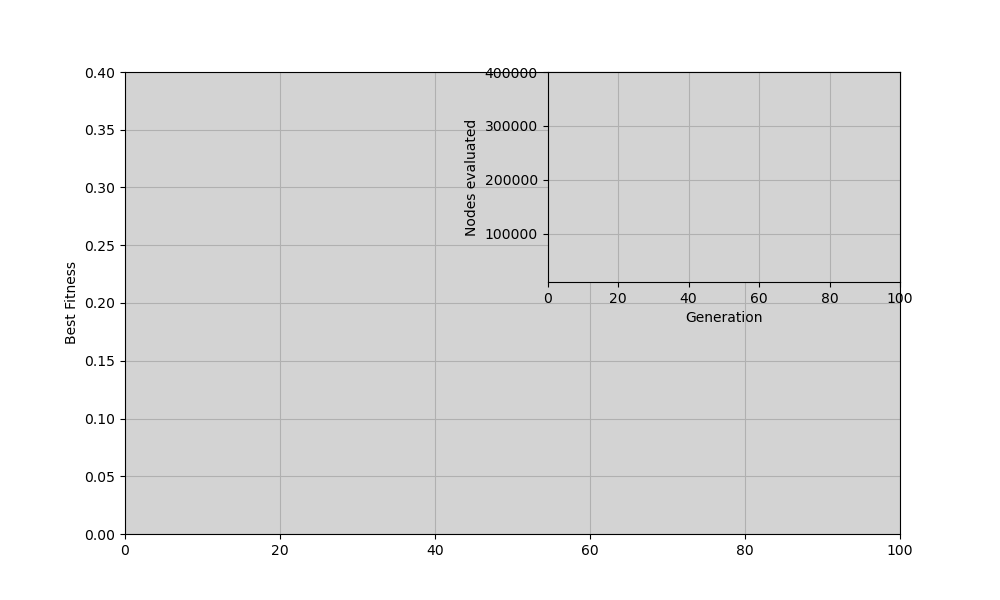

In [9]:
############################################################################################################
# The following piece of code, will allow us to display -in real time- the progress of training fitness,   #
# testing fitness and diversity decay. It is a bit overcomplicated, and it is optional of course, but it   #
# is very useful to understand and visualize if the GP is achieving convergence.                           #

x = list(range(Generations))                                                                               #

y = np.empty(Generations)                                                                                  #
y[:]=np.nan                                                                                                #
y2 = np.empty(Generations)                                                                                 #
y2[:]=np.nan                                                                                               #
d3 = np.empty(Generations)                                                                                 #
d3[:]=np.nan                                                                                               #

plt.ion()                                                                                                  #
fig = plt.figure(figsize=(10,6))                                                                                         #
ax = fig.add_subplot()                                                                                  # 
ax.set_ylabel('Best Fitness')                                                                              #
ax.set_ylim(0.0,0.4)                                                                                       #
ax.set_xlim(0,Generations)                                                                                 #
ax.set_facecolor('lightgray')                                                                              #  
ax.grid(True)                                                                                              #
ax2 = fig.add_subplot(222)                                                                                 #
ax2.set_xlabel('Generation')                                                                               #
ax2.set_ylabel('Nodes evaluated')                                                                       #
ax2.set_ylim(10000,400000)                                                                                      #
ax2.set_xlim(0,Generations)                                                                                #
ax2.set_facecolor('lightgray')                                                                             #
ax2.grid(True)                                                                                             #

line1, = ax.plot(x, y, 'b-', label='training')                                                             #
line2, = ax.plot(x, y2, 'r-', label='testing')                                                             #
line3, = ax2.plot(x, d3, 'y-')                                                                             #
ax.legend()                                                                                                #
############################################################################################################


Let's run it

In [10]:
pbar = tqdm.tqdm(total=Generations)                        
epochs = 1

i = 0                          # Notice how now we need to manually count the number of generations elapsed 
for e in range(epochs):
    
    for j in range(Generations):
        
        Population, d, bf, tf = Steady_StateMP(Population = Population,
                                               batch = x_training,           # different minibatch each cycle
                                               labels = y_training,
                                               test_batch = None,
                                               test_labels = None,
                                               l_rate = l_rate,
                                               oper = oper,
                                               oper_prob = oper_prob,
                                               oper_arity = oper_arity,
                                               minimization = minimization,
                                               sel_mechanism = sel_mechanism,
                                               online = False,
                                               pro=1)  

        # count total nodels in generation
        node_count = 0
        for individual in Population:
            node_count += individual.cost()
        
                
        diversity.append(node_count)
        fitness.append(bf)
        test_fitness.append(tf)

        # For live plotting #################
        y[i]=fitness[i]
        y2[i]=test_fitness[i]
        d3[i]=diversity[i]

        line1.set_ydata(y)
        line2.set_ydata(y2)
        line3.set_ydata(d3)

        fig.canvas.draw()
        #####################################
        
        i += 1
        pbar.update(1)
        
        diversity_arr = np.asarray(diversity)
        if diversity_arr.sum() + diversity[-1] > cost_limit:
            break        
    
pbar.close()

 50%|███████████████████████████████████████                                       | 50/100 [15:38<15:38, 18.78s/it]


The algorithm stopped at generation 50, when it estimated that another iteration would overspend the budget.

Let's print the final training fitness achieved and the computational cost:

In [11]:
print("Training fitness of best individual found: ", fitness[-1])
print("Testing  fitness of best individual found: ", test_fitness[-1])
print('')
diversity = np.asarray(diversity)
print("Total evaluated nodes in run: ", diversity.sum())

Training fitness of best individual found:  0.1310692349255344
Testing  fitness of best individual found:  None

Total evaluated nodes in run:  9960770


The results are expressed in MSE. Koza used the Sum of absolute errors, but here we will stick to MSE, which is more standard nowadays.

Let's save the model obtained:

In [12]:
ADFsolver = elite_selection(population=Population, amount=1, minimization=minimization)[0]

## Same problem without ADFs

__Let's now try the same problem but using a standard GP implementation, i.e. without ADFs__

We'll use the Simple Regressor from TurboGP library.

In [13]:
from Regressor import *

All other parameters will remain the same, 

In [14]:
# We will also use the same primitives Koza uses for this sample in his book
lowlevel = ['ADD', 'SUB', 'MUL', 'DIV']
Node.f1_set=lowlevel

Node.i2_set=[-1.0,1.0]

pop_size = 4000                              # Same population as in Koza's Book

oper = [SimpleRegresor.mutation,              # Genetic operations to use.
        SimpleRegresor.protected_crossover]   # notice how they are defined by the type of individual we will evolve

oper_prob = [.2, .8]                         # Since ADFs are all about crossover, we will give preference to XO over
oper_arity = [1, 2]                          # mutation, unlike most of the rest of TurboGP examples.

l_rate = 1.0                                 # Offspring pool size, defined as the ratio to the population size.

minimization = True                          # if it is a minimization problem or not
sel_mechanism = binary_tournament            # Preferred selection mechanism for parent selection

Let's create the initial population and evaluate it.

To level the ground, we will increase the max depth of the single function to account for a major number of nodes.

In [22]:
%%time
Population = []

for _ in range(pop_size):
    Population.append(SimpleRegresor(input_vector_size=1,
                                     complexity = 9))

CPU times: user 13.2 s, sys: 93 ms, total: 13.3 s
Wall time: 13.2 s


A max tree depth of 9 will ensure a similar number of generations elapse before the node evaluations budget is spent.

We can now evaluate the first generation,

In [23]:
%%time
#initial evaluation
for individual in Population:
        individual.fitness(x_training, y_training)

CPU times: user 5.73 s, sys: 6.27 ms, total: 5.73 s
Wall time: 5.73 s


The run limits will be the same as in the case with the ADF.

In [24]:
Generations = 100
cost_limit = 10000000 # ten million nodes

diversity = []
fitness = []
test_fitness = []

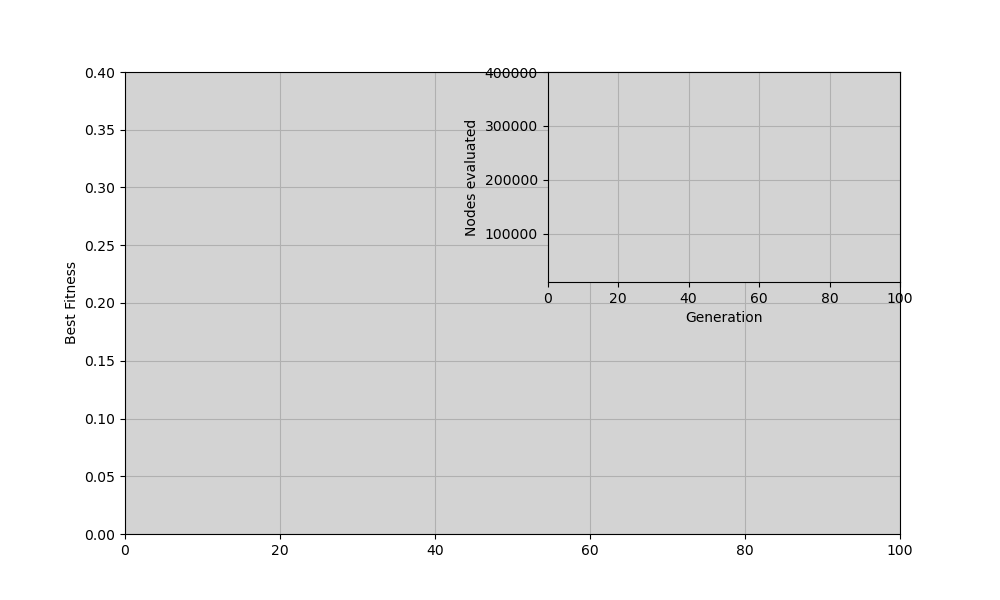

In [25]:
############################################################################################################
# The following piece of code, will allow us to display -in real time- the progress of training fitness,   #
# testing fitness and diversity decay. It is a bit overcomplicated, and it is optional of course, but it   #
# is very useful to understand and visualize if the GP is achieving convergence.                           #

x = list(range(Generations))                                                                               #

y = np.empty(Generations)                                                                                  #
y[:]=np.nan                                                                                                #
y2 = np.empty(Generations)                                                                                 #
y2[:]=np.nan                                                                                               #
d3 = np.empty(Generations)                                                                                 #
d3[:]=np.nan                                                                                               #

plt.ion()                                                                                                  #
fig = plt.figure(figsize=(10,6))                                                                                         #
ax = fig.add_subplot()                                                                                  # 
ax.set_ylabel('Best Fitness')                                                                              #
ax.set_ylim(0.0,0.4)                                                                                       #
ax.set_xlim(0,Generations)                                                                                 #
ax.set_facecolor('lightgray')                                                                              #  
ax.grid(True)                                                                                              #
ax2 = fig.add_subplot(222)                                                                                 #
ax2.set_xlabel('Generation')                                                                               #
ax2.set_ylabel('Nodes evaluated')                                                                       #
ax2.set_ylim(10000,400000)                                                                                      #
ax2.set_xlim(0,Generations)                                                                                #
ax2.set_facecolor('lightgray')                                                                             #
ax2.grid(True)                                                                                             #

line1, = ax.plot(x, y, 'b-', label='training')                                                             #
line2, = ax.plot(x, y2, 'r-', label='testing')                                                             #
line3, = ax2.plot(x, d3, 'y-')                                                                             #
ax.legend()                                                                                                #
############################################################################################################

In [26]:
pbar = tqdm.tqdm(total=Generations)                        
epochs = 1

i = 0                          # Notice how now we need to manually count the number of generations elapsed 
for e in range(epochs):
    
    for j in range(Generations):
        
        Population, d, bf, tf = Steady_StateMP(Population = Population,
                                               batch = x_training,           # different minibatch each cycle
                                               labels = y_training,
                                               test_batch = None,
                                               test_labels = None,
                                               l_rate = l_rate,
                                               oper = oper,
                                               oper_prob = oper_prob,
                                               oper_arity = oper_arity,
                                               minimization = minimization,
                                               sel_mechanism = sel_mechanism,
                                               online = False,
                                               pro=10)  
        
        # count total nodels in generation
        node_count = 0
        for individual in Population:
            node_count += individual.cost()
        
                
        diversity.append(node_count)
        fitness.append(bf)
        test_fitness.append(tf)

        # For live plotting #################
        y[i]=fitness[i]
        y2[i]=test_fitness[i]
        d3[i]=diversity[i]

        line1.set_ydata(y)
        line2.set_ydata(y2)
        line3.set_ydata(d3)

        fig.canvas.draw()
        #####################################
        
        i += 1
        pbar.update(1)
        
        diversity_arr = np.asarray(diversity)
        if diversity_arr.sum() + diversity[-1] > cost_limit:
            break  
    
pbar.close()

 45%|███████████████████████████████████                                           | 45/100 [06:57<08:30,  9.28s/it]


In [27]:
print("Training fitness of best individual found: ", fitness[-1])
print("Testing  fitness of best individual found: ", test_fitness[-1])
print('')
diversity = np.asarray(diversity)
print("Total evaluated nodes in run: ", diversity.sum())

Training fitness of best individual found:  0.1416112099758705
Testing  fitness of best individual found:  None

Total evaluated nodes in run:  9871160


Let's save the best model.

In [28]:
Genericsolver = elite_selection(population=Population, amount=1, minimization=minimization)[0]

We obtained a slightly worse performance given approximately the same computational cost. 

If we perform an statistical trial of several runs of the ADF version against the standard one, these results will be confirmed. The ADF equipped GP will have a tiny performance advantage, in average, over the regular GP, given the same computational resources.

TurboGP comes with a few scripts to perform such study. The gains of the ADF version will be minimal, but remember that Koza established this problem to be at the borderline between problems that could be taken advantage of modularity, so it is normal that huge gains are difficult to observe.

As matter of fact, if we plot the behavior of the obtained models, no difference will be visually noticeable. Let's do so.

## Plotting approximations obtained by each one of the two approaches.

__Let's start with the one without the ADFs__

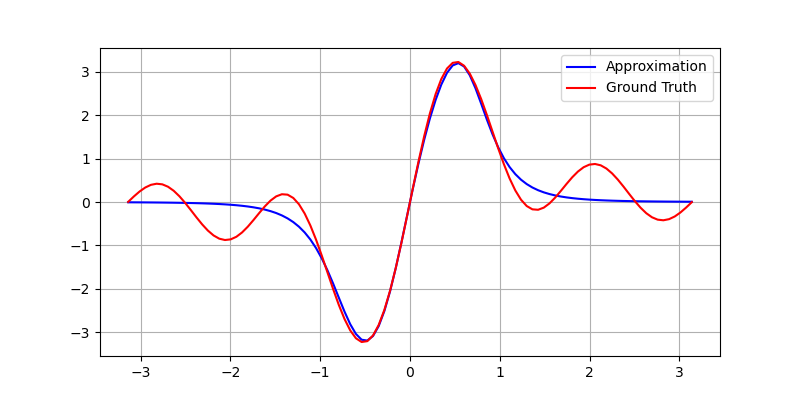

In [29]:
x = x_training

y = np.zeros(100)
y2 = y_training

for i in range(100):
    y[i] = Genericsolver.predict(x[i])
#    y2[i] = np.sin(x[i])


fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.grid(True)

line1, = ax.plot(x, y, 'b-', label='Approximation')
line2, = ax.plot(x, y2, 'r-', label='Ground Truth')

ax.legend()
plt.show()

__Now the approximation of the model obtained by the ADF equipped GP__

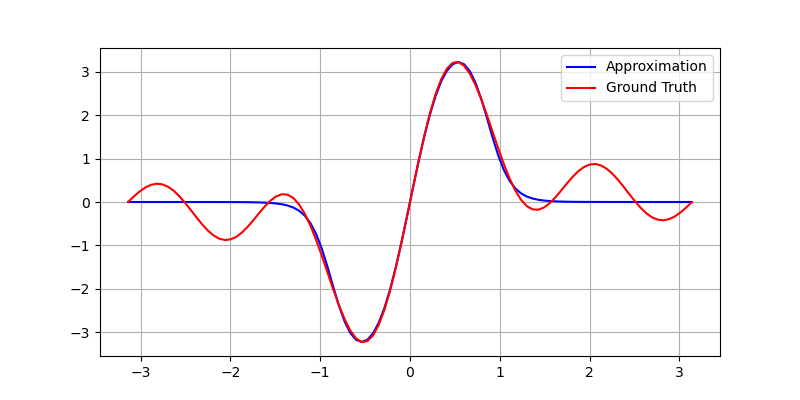

In [30]:
x = x_training

y = np.zeros(100)
y2 = y_training

for i in range(100):
    y[i] = ADFsolver.predict(x[i])
#    y2[i] = np.sin(x[i])


fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.grid(True)

line1, = ax.plot(x, y, 'b-', label='Approximation')
line2, = ax.plot(x, y2, 'r-', label='Ground Truth')

ax.legend()
plt.show()

We can notice that the ADF GP better fit the main sine function at the center, but neither of both approaches managed to approximate the harmonics.